In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform

import pickle

/tmp/ipykernel_8329/3995731895.py:4: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


count    1.362152e+06
mean     2.348851e+00
std      1.960910e+00
min      0.000000e+00
25%      1.091294e+00
50%      1.808731e+00
75%      2.969809e+00
max      3.541035e+01
Name: Radius, dtype: float64

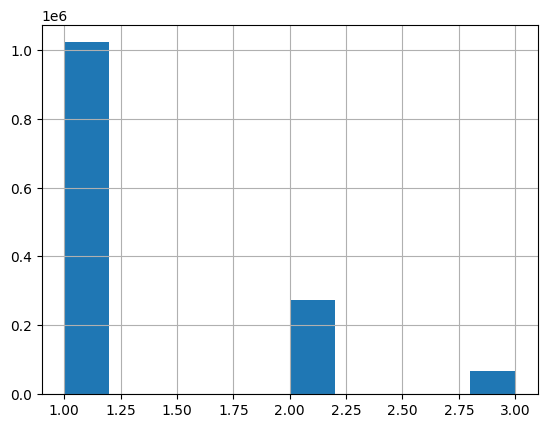

In [2]:
mainSeed = 971215728
np.random.seed(mainSeed)

PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()

complexVib = PCAData["ESP Vibration X"]+1j*PCAData["ESP Vibration Y"]

PCAData["VibMod"] = np.absolute(complexVib)
PCAData["VibArc"] = np.angle(complexVib)

PCAData["Radius Category"] = pd.qcut(PCAData["Radius"],q=[0,.75,.95,1],labels=[1,2,3]).astype(int)
PCAData["Radius Category"].hist()
PCAData["Radius"].describe()


In [3]:
proportion = 0.75

X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,PCAData)

totalLength = np.concatenate([trainLength,testLength])

modelData = pd.concat([X_train,X_test])

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)


In [4]:
modelCat = modelCat = hmm.CategoricalHMM(n_components=2,random_state=mainSeed)
modelCat = li.HMMTrainer(X_train["Radius Category"],trainLength,modelCat)
li.PostProcessing(modelCat, PCAData, modelData,"Radius Category", "State Cat", totalLength)
print(modelCat.get_stationary_distribution())
PCAData["State Cat"] = PCAData["State Cat"].map(li.StateConversion(modelCat.get_stationary_distribution(),2))


AIC: 326321.99026286794 BIC: 326426.839010521
[0.29061406 0.70938594]


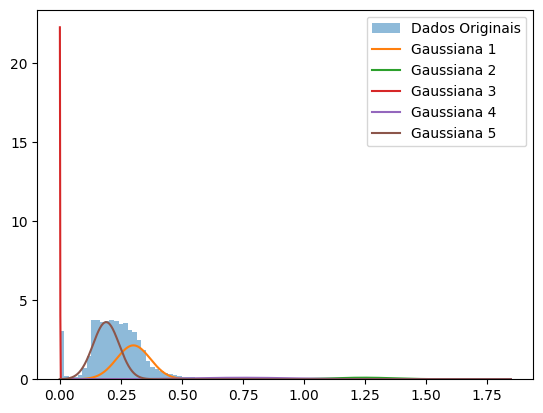

AIC: -995772.7004358066 BIC: -995458.1541928475
[0.79866509 0.20133491]


In [5]:
n = 5

data = PCAData["VibMod"].loc[PCAData["Well_down"]==0].apply(np.log1p)

model = li.GMMFit(data,n,mainSeed)
li.GaussianMixturePlot(model,data)

modelVib = hmm.GMMHMM(
    n_components=2,
    n_mix= n,
    random_state=mainSeed,
    covariance_type="full"
    )


modelVib = li.HMMTrainer(X_train["VibMod"],trainLength,modelVib)

li.PostProcessing(modelVib, PCAData, modelData,"VibMod", "State Mod", totalLength)
print(modelVib.get_stationary_distribution())
PCAData["State Mod"] = PCAData["State Mod"].map(li.StateConversion(modelVib.get_stationary_distribution(),2))



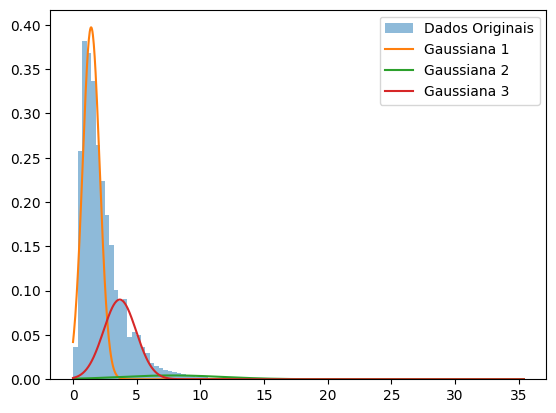

AIC: 2432682.002499069 BIC: 2432845.100550974
[0.18958001 0.26491661 0.54550338]


In [ ]:
n = 3
data = PCAData["Radius"]

model = li.GMMFit(data,n)
li.GaussianMixturePlot(model,data)

modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    init_params="t",
    algorithm="map"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

li.PostProcessing(modelRadius, PCAData, modelData,"Radius", "State Radius", totalLength)
print(modelRadius.get_stationary_distribution())
PCAData["State Radius"] = PCAData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))



In [55]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [2, 2, 3]

(<Figure size 6000x3000 with 3 Axes>,
 array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
        <Axes: xlabel='time'>], dtype=object))

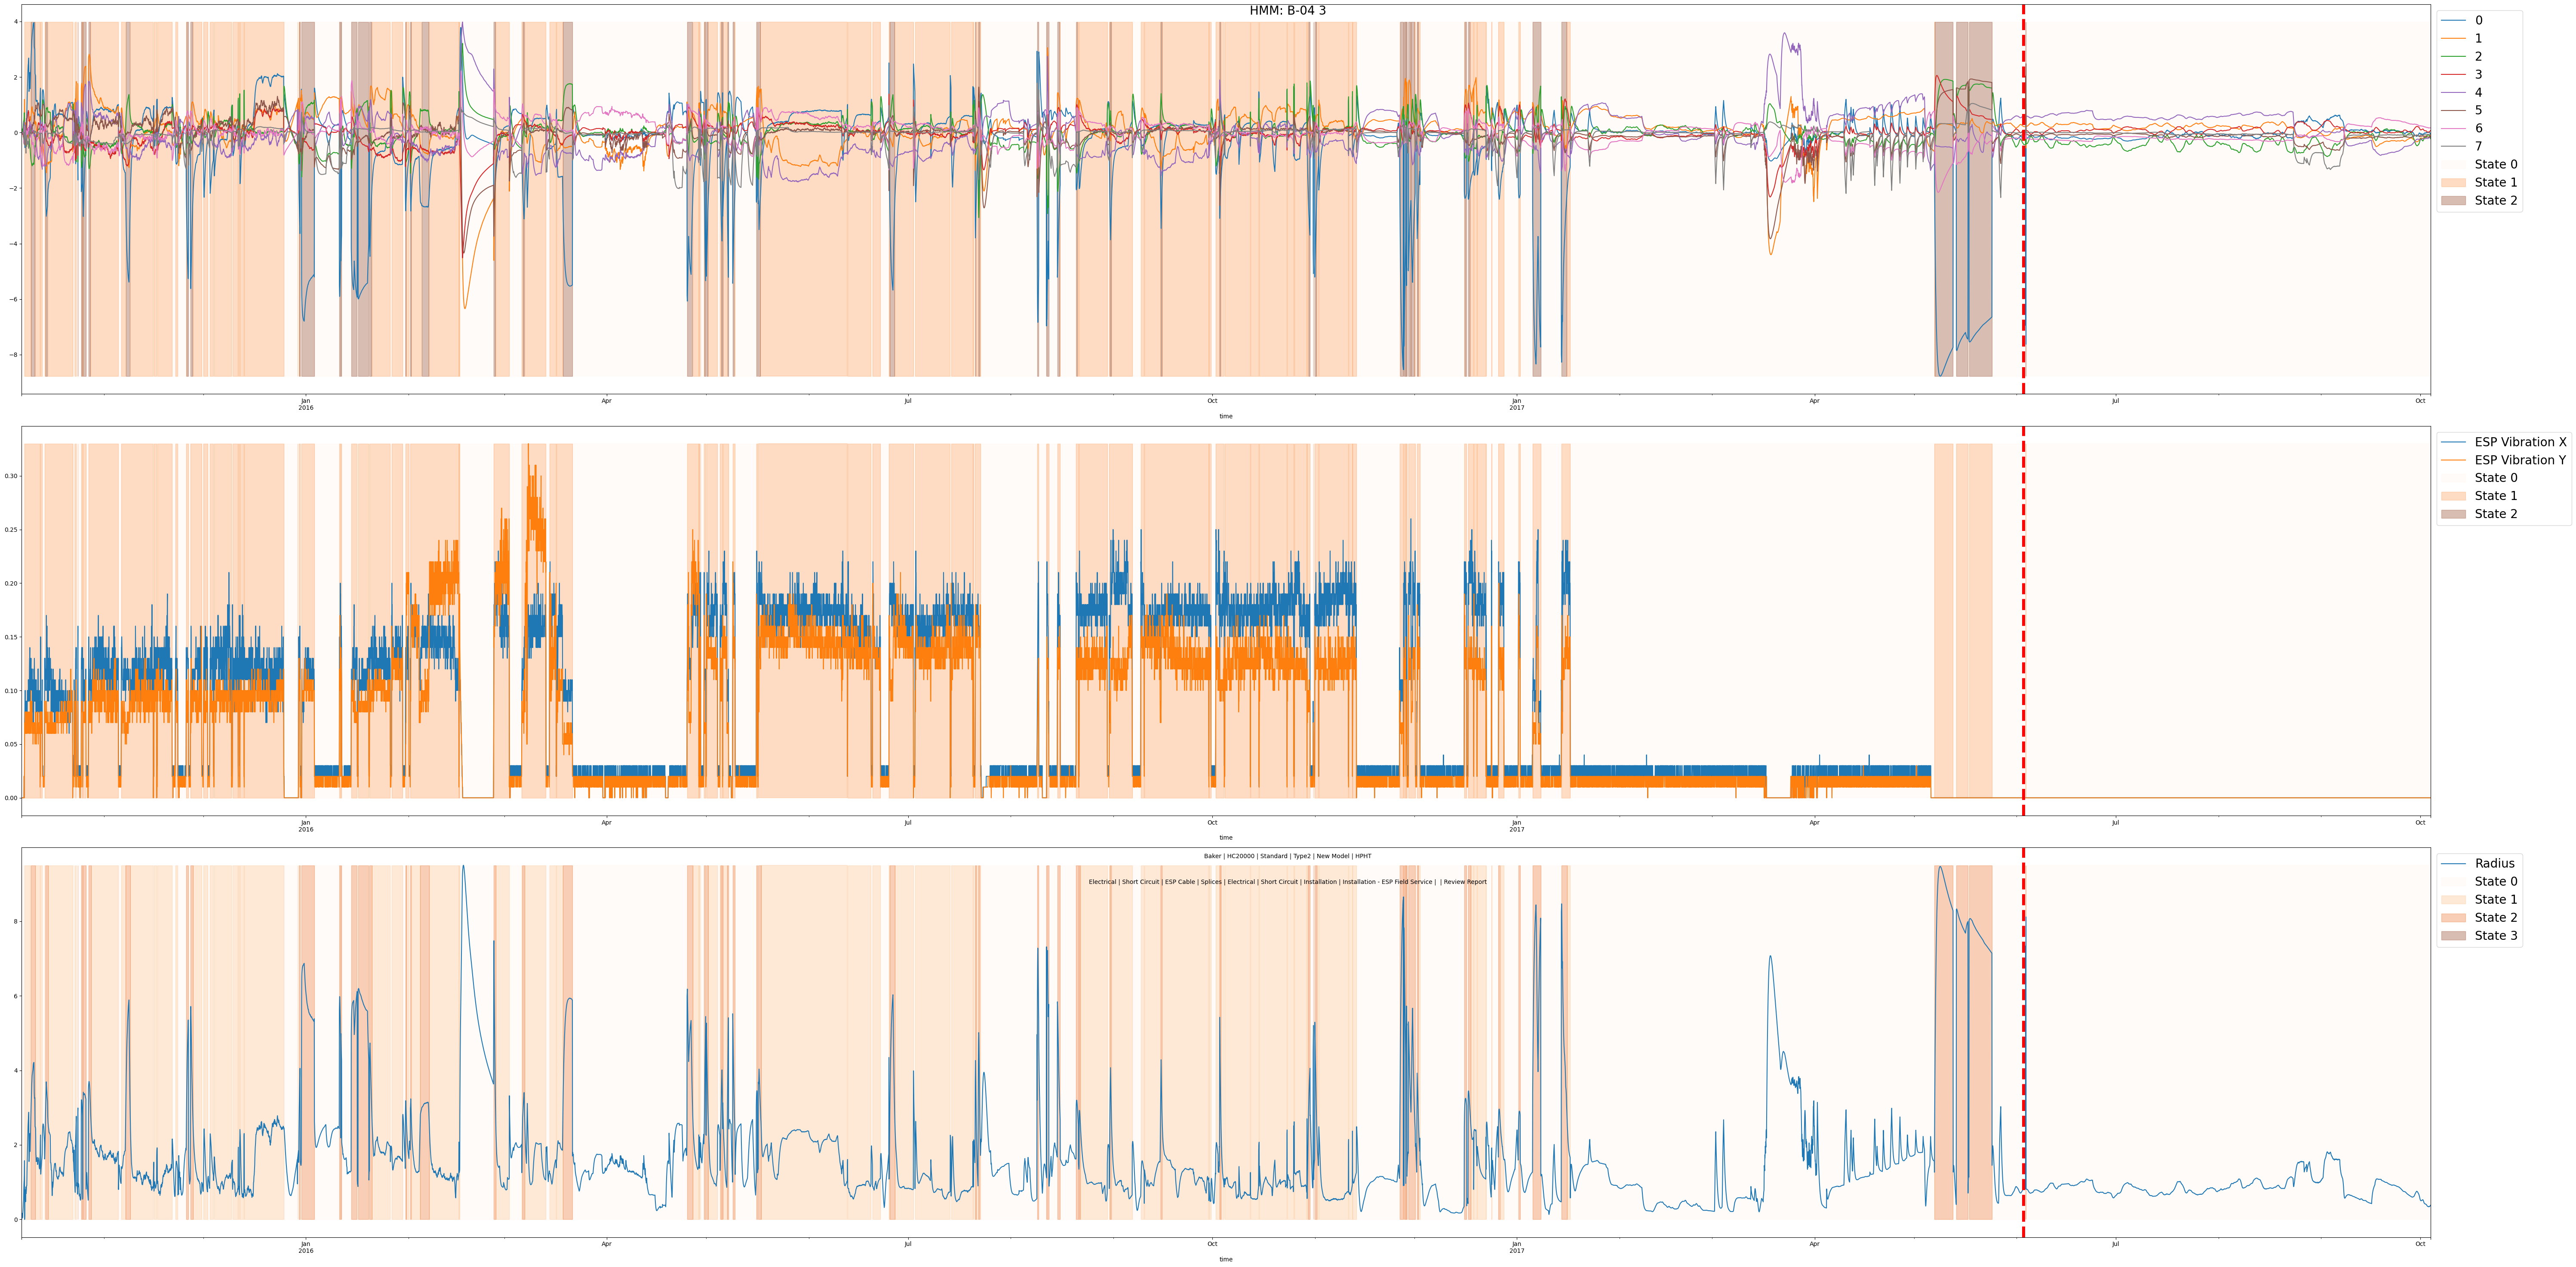

In [57]:
pump = pumpList[56]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
li.HMMPicture(pumpData,pump,PCAHeaders, [PCAHeaders,vibeHeader, "Radius"],["State Cat","State Mod","State Radius"], n)


In [43]:
modelRadius.transmat_

array([[0.99891861, 0.00108139],
       [0.00292042, 0.99707958]])

In [8]:
# PCAData[["Transformed Radius","VibNormX","VibNormY"]] = 0.0

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]#.copy()
#     PCAData.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
#     PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
#     PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

In [9]:
# #modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],covar_type="diag")
# # pickle.dump(modelSq,open("MLmodels/modelSq.sav","wb"))

# modelSq = pickle.load(open("MLmodels/modelSq.sav","rb"))

# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))

# #modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],covar_type="full")
# # pickle.dump(modelVib,open("MLmodels/modelVib.sav","wb"))

# modelVib = pickle.load(open("MLmodels/modelVib.sav","rb"))
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

# #modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],covar_type="full")
# #pickle.dump(modelTot,open("MLmodels/modelTot.sav","wb"))

# modelTot = pickle.load(open("MLmodels/modelTot.sav","rb"))
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))


# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM/"+pump)
#     plt.close()

In [10]:
List = ["a","b",["colossal","teste"]]

len(List)

3

In [11]:
# numberOfDays = 7

# stats = pd.DataFrame(columns=["State Vib", "State Gaussian","State Tot"])

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]
#     if pumpData.loc[pumpData["Failure"]==1].empty != True:
#         failure = pumpData.loc[pumpData["Failure"]==1].index[0]
#         indexRef = pumpData.index[0]
#         selectedData = pumpData.iloc[failure-indexRef-numberOfDays*24:]

#         stats = pd.concat([stats, 
#                        selectedData.loc[selectedData["Well_down"]==0][["State Vib", "State Gaussian","State Tot"]]])

    

In [12]:
# stats.reset_index(inplace=True,drop=True)
# stats = stats.infer_objects()
# stats.drop(labels=0,inplace=True)
# stats.hist()


In [13]:
# modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],algorithm="map")
# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))
# pickle.dump(modelSq,open("modelSq_map.sav","wb"))

# modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],algorithm="map")
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))
# pickle.dump(modelVib,open("modelVib_map.sav","wb"))

# modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],algorithm="map")
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))
# pickle.dump(modelTot,open("modelTot.sav","wb"))

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM_map/"+pump)
#     plt.close()

In [14]:
# pump = pumpList[0]

# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)

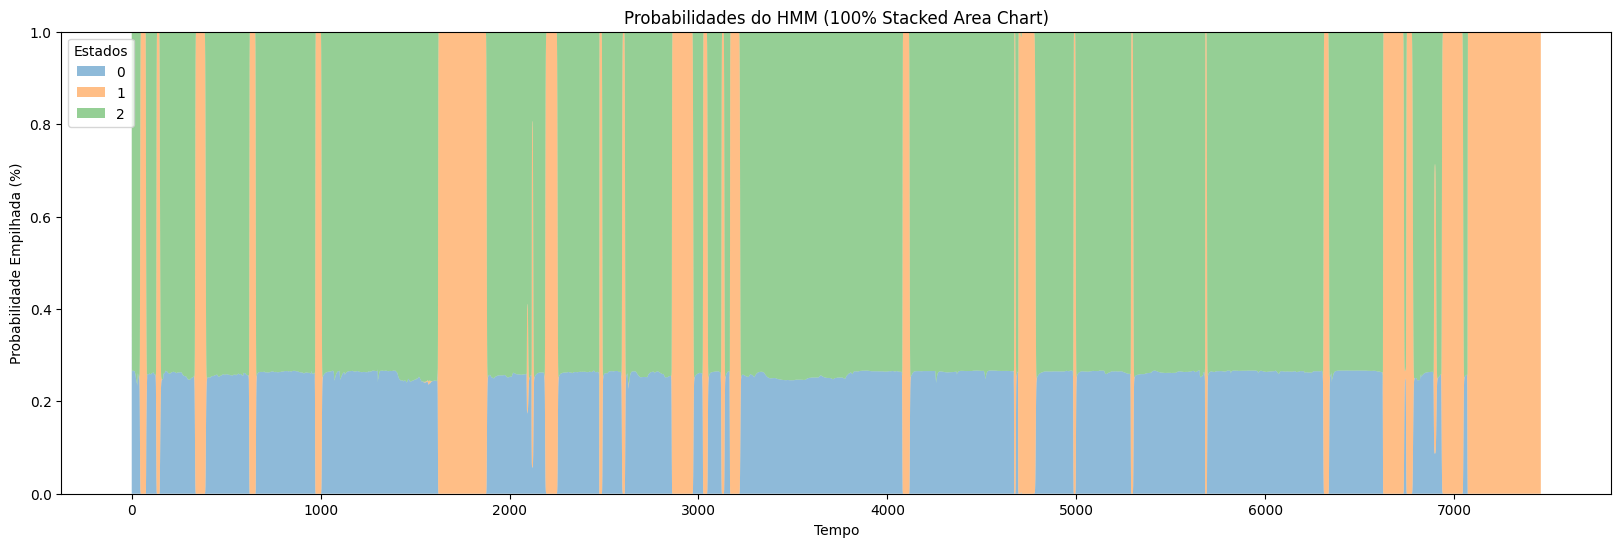

In [58]:
totalReshaped = pumpData["Radius"].loc[pumpData["Well_down"]==0].to_numpy().reshape(-1,1)


df = pd.DataFrame(modelRadius.predict_proba(totalReshaped))

# Índices de tempo
time = np.arange(len(df))

# Criar figura
fig, ax = plt.subplots(figsize=(20, 6))

# Cores para os estados
colors = ['#1f77b4', '#ff7f0e', '#2ca02c','#4cff2c','#fcff2c']

# Gráfico de área empilhada com transparência (alpha)
ax.stackplot(time, df.T, labels=df.columns, colors=colors, alpha=0.5)

# Configurações do gráfico
ax.set_xlabel("Tempo")
ax.set_ylabel("Probabilidade Empilhada (%)")
ax.set_title("Probabilidades do HMM (100% Stacked Area Chart)")
ax.legend(title="Estados", loc='upper left')
plt.ylim(0, 1)  # Mantém o eixo Y de 0 a 1 (100%)

# Exibir o gráfico
plt.show()


In [16]:
# for pump in pumpList:
   
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [17]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [18]:
# pump = pumpList[0]
# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# plt.rcParams['font.size'] = 15.0
# pumpData["time"] = pd.to_datetime(pumpData["time"])
# pumpData.set_index("time",inplace=True)

# pumpData = pumpData.asfreq('h',fill_value=0)

# pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)


# # Preenchendo as áreas de a
# # cordo com os estados
# for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"State {state}")

#         ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



# if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#         #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#         ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


# fig.suptitle("HMM: " + pump,fontsize=20);
# fig.savefig("imagens/relatorio/hmm")